# Download & Unpack ZIP

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_id = "15kxsv3BiN-9iQrpyzobKNl_oFhWWOwDr"
zip_path = "/content/drive/MyDrive/potsdam/Potsdam-GeoTif.zip"
extract_path = "/content/potsdam"

import os
# Create folder in drive if it does not exist
os.makedirs(os.path.dirname(zip_path), exist_ok=True)

# Download only if not already in drive
if not os.path.exists(zip_path):
    !gdown --id $file_id -O $zip_path
else:
    print("Dataset already exists in Drive")

expectedFile = os.path.join(extract_path, "Potsdam-GeoTif")
# Unpack only if not already unpacked
if not os.path.exists(expectedFile):
    os.makedirs(extract_path, exist_ok=True)
    !unzip -q $zip_path -d $extract_path
else:
    print("ZIP already unpacked")

print("Download & Unpack complete")

Dataset already exists in Drive
Download & Unpack complete


# Step 1 / Dataset preparation






In [ ]:
import glob

tifs = glob.glob("/content/potsdam/**/*.tif", recursive=True)

# Sanity check
print("Number of files:", len(tifs))

Number of files: 15048


In [ ]:
import random
import numpy as np
random.seed(42)

# Select 5000 samples from dataset
nSamples = 5000
allFiles = tifs.copy()
sampledFiles = random.sample(allFiles, nSamples)

# Sanity check
print("Sampled files:", len(sampledFiles))

Sampled files: 5000


In [ ]:
# Get folds from dataset
def createFolds(fileList, nFolds=5):
    random.shuffle(fileList)
    folds = np.array_split(fileList, nFolds)
    return folds

# Call createFolds and sanity check
folds = createFolds(sampledFiles, nFolds=5)
for i in range(len(folds)):
    fold = folds[i]
    print(f"Fold {i+1}: {len(fold)} files")

Fold 1: 1000 files
Fold 2: 1000 files
Fold 3: 1000 files
Fold 4: 1000 files
Fold 5: 1000 files


In [ ]:
# Assign folds
trainFiles = list(folds[0]) + list(folds[1]) + list(folds[2])
valFiles   = list(folds[3])
testFiles  = list(folds[4])

# Sanity check
print("Train:", len(trainFiles))
print("Val:", len(valFiles))
print("Test:", len(testFiles))

Train: 3000
Val: 1000
Test: 1000


In [ ]:
# Create tfrecord for each fold
# Serializer
import tensorflow as tf
imgSize = 224
nBands = 5

def serializeTFR(image, label):
    image = image.astype(np.float32)
    label = label.astype(np.uint8)

    feature = {
        "image": tf.train.Feature(
            bytes_list=tf.train.BytesList(
                value=[image.tobytes()]
            )
        ),
            "label": tf.train.Feature(
            bytes_list=tf.train.BytesList(
                value=[label.tobytes()]
            )
        ),
    }
    example = tf.train.Example(
        features = tf.train.Features(feature=feature)
    )
    return example.SerializeToString()

# Writer
import rasterio as rio
def writeTFRecord(tilePaths, tfrecordPath):

    with tf.io.TFRecordWriter(tfrecordPath) as writer:
        for blob in tilePaths:
            with rio.open(blob) as img:
                imgArray = img.read().transpose(1, 2, 0).astype(np.float32)

            image = imgArray[:, :, 0:5]
            label = imgArray[:, :, 5].astype(np.uint8)

            example = serializeTFR(image, label)
            writer.write(example)

    print("Finished writing:", tfrecordPath)

In [ ]:
# Create TFRecords for each fold

tfRecordOutputDir = "/content/drive/MyDrive/potsdam/tfrecords"

os.makedirs(tfRecordOutputDir, exist_ok=True)

allExist = all(
    os.path.exists(os.path.join(tfRecordOutputDir, f"fold_{i}.tfrecord"))
    for i in range(5)
)

if not allExist:
    print("TFRecords not found, creating one for each fold.")

    for i, fold in enumerate(folds):
        tfrecordPath = os.path.join(tfRecordOutputDir, f"fold_{i}.tfrecord")
        writeTFRecord(fold, tfrecordPath)
else:
    print("TFRecords already exist, skipping creation.")


TFRecords already exist, skipping creation.


In [ ]:
import matplotlib.pyplot as plt

PathToGeoTiffFile = "/content/potsdam/Potsdam-GeoTif"
print("Path set to:", PathToGeoTiffFile)

Path set to: /content/potsdam/Potsdam-GeoTif


In [ ]:
allTiles = glob.glob(PathToGeoTiffFile + "/*.tif")

for tile in allTiles:
    if "0000000224-0000042784.tif" not in tile:
        blob = tile
        break

print("Using:", blob)

Using: /content/potsdam/Potsdam-GeoTif/0000029344-0000041440.tif


In [ ]:
import rasterio as rio
img = rio.open(blob)
imgArray = img.read().transpose(1, 2, 0)

print("Shape:", imgArray.shape)

Shape: (224, 224, 6)


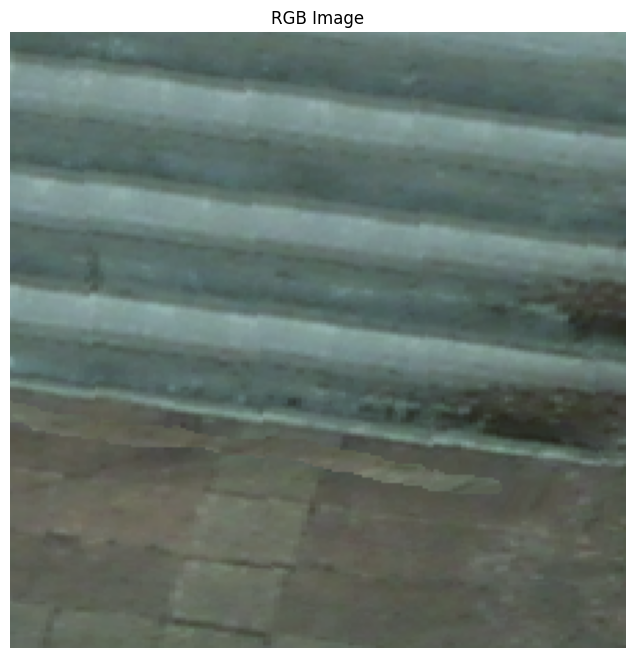

In [ ]:
# Visualize RGB
plt.figure(figsize=(24,8))
plt.imshow(imgArray[:,:,0:3] / 255.0)
plt.title("RGB Image")
plt.axis("off")
plt.show()

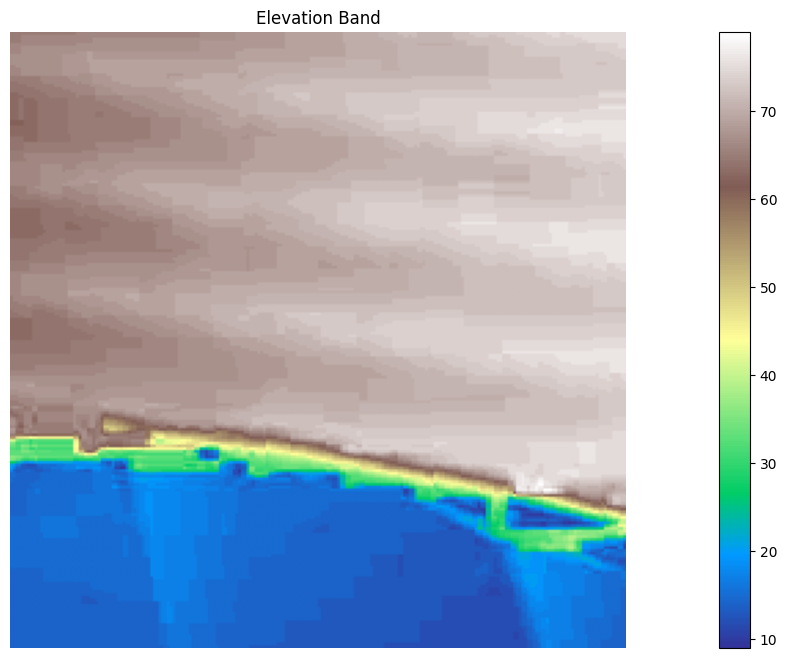

[[65. 65. 65. ... 75. 75. 75.]
 [65. 65. 65. ... 75. 75. 75.]
 [65. 65. 65. ... 75. 75. 75.]
 ...
 [14. 14. 14. ... 14. 14. 14.]
 [14. 14. 14. ... 14. 14. 14.]
 [14. 14. 14. ... 14. 14. 14.]]


In [ ]:
# Visualize Elevation Band
plt.figure(figsize=(24,8))
plt.imshow(imgArray[:,:,4], cmap="terrain")
plt.title("Elevation Band")
plt.colorbar()
plt.axis("off")
plt.show()
print(imgArray[:,:,4])

In [ ]:
# Checking target band classes

labelBand = imgArray[:, :, 5].astype(np.int32)

print("Unique label values:", np.unique(labelBand))

Unique label values: [0 1 3]


In [ ]:
import matplotlib.colors as mcolors

classNames = [
    "Impervious surface",   # 0
    "Building",             # 1
    "Tree",                 # 2
    "Low vegetation",       # 3
    "Car",                  # 4
    "Clutter/Background"    # 5
]

cmap = mcolors.ListedColormap([
    "red",          # 0
    "yellow",       # 1
    "lightblue",    # 2
    "green",        # 3
    "orange",       # 4
    "gray"          # 5
])

colors = ([
    "red",          # 0
    "yellow",       # 1
    "lightblue",    # 2
    "green",        # 3
    "orange",       # 4
    "gray"          # 5
])

print("Colormap set")

Colormap set


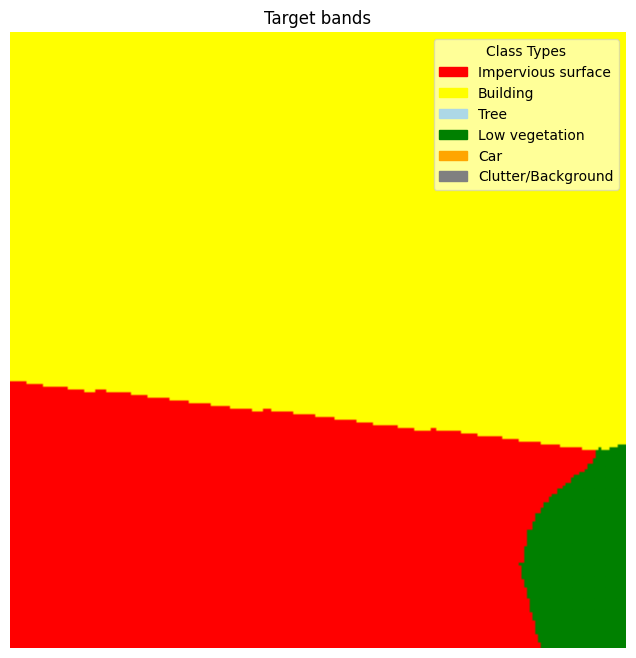

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Plot target bands sample
plt.figure(figsize=(24,8))

plt.imshow(labelBand, cmap=cmap, vmin=0, vmax=5)
plt.title("Target bands")
plt.axis("off")

patches = [mpatches.Patch(color=colors[i], label=classNames[i])for i in range(6)]

plt.legend(handles=patches, title="Class Types", loc="upper right", framealpha=0.6)

# Parse the TFRecords to be usable in training


In [ ]:
imgSize = 224
nBands = 5

# File parser
def parseTFRecord(tfrecordFile):

    featureDescription = {
        "image": tf.io.FixedLenFeature([], tf.string),
        "label": tf.io.FixedLenFeature([], tf.string),
    }

    parsed = tf.io.parse_single_example(tfrecordFile,
                                        featureDescription)

    image = tf.io.decode_raw(parsed["image"], tf.float32)
    label = tf.io.decode_raw(parsed["label"], tf.uint8)

    image = tf.reshape(image, [imgSize, imgSize, nBands])
    label = tf.reshape(label, [imgSize, imgSize])

    return image, label

In [ ]:
# We do not parse here, because we need to shuffle before parsing.
def loadFold(foldId, tfRecordDir):
    path = f"{tfRecordDir}/fold_{foldId}.tfrecord"
    return tf.data.TFRecordDataset(path)

### Preprocess sets

In [ ]:
# Load folds
tfRecordDir = "/content/drive/MyDrive/potsdam/tfrecords"

train_raw = (
    loadFold(0, tfRecordDir)
    .concatenate(loadFold(1, tfRecordDir))
    .concatenate(loadFold(2, tfRecordDir))
)

val_raw = loadFold(3, tfRecordDir)
test_raw = loadFold(4, tfRecordDir)

In [ ]:
# Get mean and standard deviation for each band

statsDataset = (
    train_raw
    .map(parseTFRecord, num_parallel_calls=tf.data.AUTOTUNE)
)

sum_channels = np.zeros(nBands)
sum_sq_channels = np.zeros(nBands)
n_pixels_total = 0

# Only compute in training set
for image, _ in statsDataset:
    img = image.numpy()

    sum_channels += img.sum(axis=(0,1))
    sum_sq_channels += (img**2).sum(axis=(0,1))

    n_pixels_total += img.shape[0] * img.shape[1]

mean = sum_channels / n_pixels_total

std = np.sqrt(
    (sum_sq_channels / n_pixels_total) - (mean ** 2)
)

print("Mean:", mean)
print("Std:", std)

Mean: [85.90471266 92.11441114 85.45670063 97.68796248 45.77032256]
Std: [35.31580033 34.86368139 36.5266585  35.68054817 54.39487369]


In [ ]:
# Improve generalization by data augmentation
def augment(image, label):
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        label = tf.image.flip_left_right(label[..., tf.newaxis])[..., 0]

    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        label = tf.image.flip_up_down(label[..., tf.newaxis])[..., 0]

    k = tf.random.uniform((), minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    label = tf.image.rot90(label[..., tf.newaxis], k)[..., 0]

    return image, label

In [ ]:
# Slice out elevation for step 2
mean_tf2 = tf.constant(mean[:4], dtype=tf.float32)
std_tf2  = tf.constant(std[:4], dtype=tf.float32)

# Standardize and apply one hot encoding for label
def preprocessStep2(image, label):
    image = image[..., :4]
    image = (image - mean_tf2) / std_tf2
    label = tf.one_hot(label, depth=6)
    return image, label

# Shuffle considers a 1000 size window to shuffle
# Batch is for instead of updating the network in each image, it will update every 8 images
# Prefetch allows cpu preparing next batch while gpu training current
train_dataset = (
    train_raw
    .shuffle(1000)
    .map(parseTFRecord, num_parallel_calls=tf.data.AUTOTUNE)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .map(preprocessStep2, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(8)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    val_raw
    .map(parseTFRecord, num_parallel_calls=tf.data.AUTOTUNE)
    .map(preprocessStep2, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(8)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    test_raw
    .map(parseTFRecord, num_parallel_calls=tf.data.AUTOTUNE)
    .map(preprocessStep2, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(8)
    .prefetch(tf.data.AUTOTUNE)
)

In [ ]:
# Checking standardization
for image, label in train_dataset.take(1):
    print(image[0])

tf.Tensor(
[[[-0.799409   -0.9029655  -0.9021025   1.4857925 ]
  [-0.5166184  -0.58735013 -0.5727914   1.8504827 ]
  [-0.4600603  -0.5299655  -0.43557847  1.8785359 ]
  ...
  [-0.68629277 -0.7308116  -0.8746599   1.2052616 ]
  [-0.71457183 -0.7595039  -0.8746599   1.317474  ]
  [-0.7428509  -0.7308116  -0.8472173   1.4296863 ]]

 [[-0.799409   -0.9029655  -0.9021025   1.4857925 ]
  [-0.5166184  -0.58735013 -0.5727914   1.8504827 ]
  [-0.4600603  -0.5299655  -0.43557847  1.8785359 ]
  ...
  [-0.68629277 -0.7308116  -0.8746599   1.2052616 ]
  [-0.71457183 -0.7595039  -0.8746599   1.317474  ]
  [-0.7428509  -0.7308116  -0.8472173   1.4296863 ]]

 [[-0.71457183 -0.8168886  -0.7923321   1.7943766 ]
  [-0.6297347  -0.7308116  -0.6825618   1.7943766 ]
  [-0.5731765  -0.673427   -0.54534876  1.7943766 ]
  ...
  [-0.8842461  -0.98904234 -1.0667579   0.9247307 ]
  [-0.799409   -0.9029655  -0.9021025   1.2052616 ]
  [-0.4600603  -0.5299655  -0.4904636   1.7663234 ]]

 ...

 [[-0.4035022  -0.55865

# Step 2 / Training a simple model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 6)    │         1,734 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,918 (11.40 KB)

 Trainable params: 2,918 (11.40 KB)

 Non-trainable params: 0 (0.00 B)

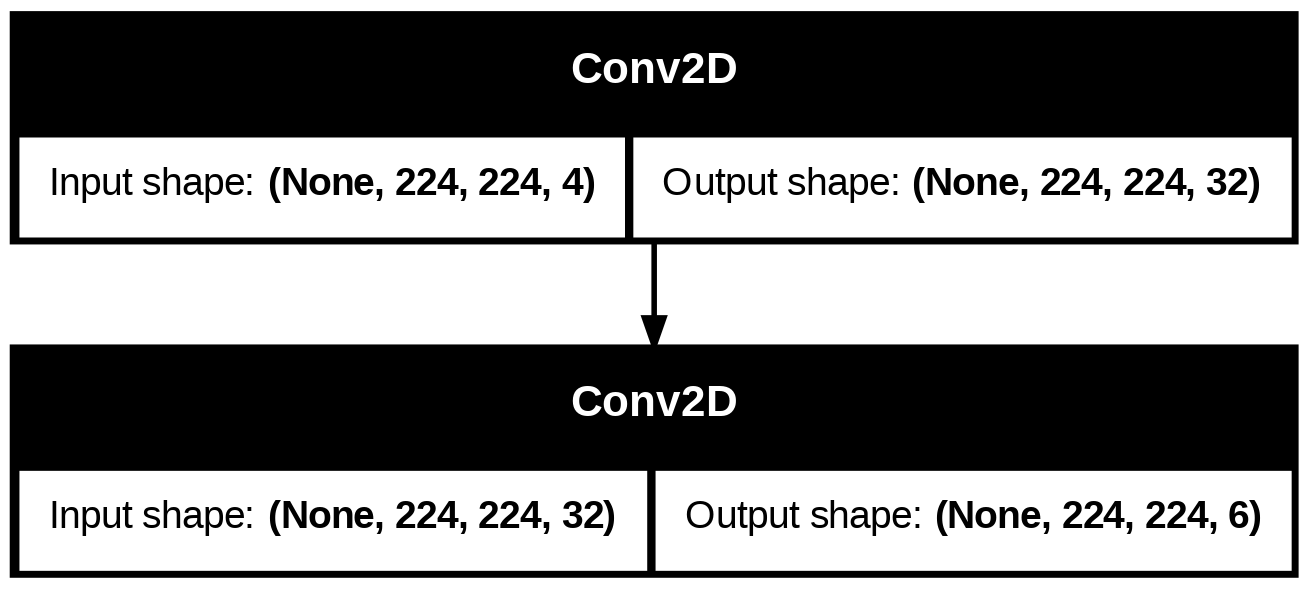

In [ ]:
import tensorflow as tf

imgSize = 224
nClasses = 6

# Create convolution layers
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(imgSize, imgSize, 4)),

    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        padding="same",
        activation="relu"
    ),

    tf.keras.layers.Conv2D(
        filters=nClasses,
        kernel_size=(3,3),
        padding="same",
        activation="softmax"
    )
])

# Show model parameters and model architecture image
model.summary()
tf.keras.utils.plot_model(model, show_shapes=True)

In [ ]:
# Compile model with Adam Optimizer, Cross entropy and accuracy
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [ ]:
# Save the best model in training
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

In [ ]:
# Train model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[checkpoint]
)

Epoch 1/20
    375/Unknown 24s 46ms/step - accuracy: 0.4288 - loss: 1.3535

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from inf to 1.11947, saving model to best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 51s 119ms/step - accuracy: 0.4290 - loss: 1.3532 - val_accuracy: 0.5505 - val_loss: 1.1195
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5695 - loss: 1.0738
Epoch 2: val_loss improved from 1.11947 to 1.05242, saving model to best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.5695 - loss: 1.0738 - val_accuracy: 0.5782 - val_loss: 1.0524
Epoch 3/20
374/375 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5949 - loss: 1.0220
Epoch 3: val_loss improved from 1.05242 to 1.02619, saving model to best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 27s 58ms/step - accuracy: 0.5949 - loss: 1.0220 - val_accuracy: 0.5904 - val_loss: 1.0262
Epoch 4/20
374/375 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5971 - loss: 1.0196
Epoch 4: val_loss did not improve from 1.02619
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.5971 - loss: 1.0196 - val

In [ ]:
import matplotlib.pyplot as plt

# Plot train and validation loss
plt.figure()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.show()

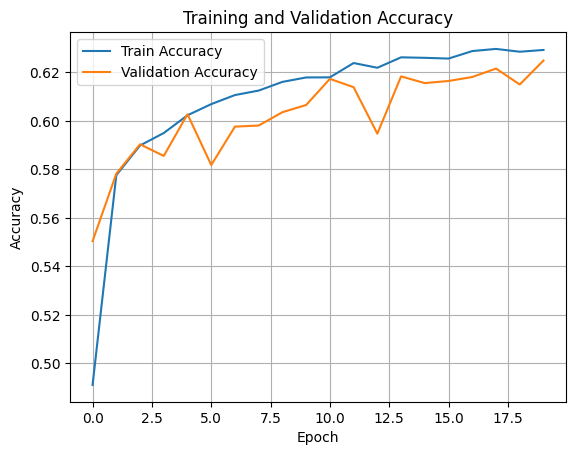

In [ ]:
# Plot train and validation accuracy
plt.figure()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Load best model and run it on test set

best_model = tf.keras.models.load_model("best_model.keras")

test_loss, test_acc = best_model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

125/125 ━━━━━━━━━━━━━━━━━━━━ 26s 170ms/step - accuracy: 0.6190 - loss: 0.9500
Test Loss: 0.9238972067832947
Test Accuracy: 0.6339982748031616


# Step 3 / Training an Encoder-Decoder model

In [ ]:
# Mean and std for 5 bands
mean_tf = tf.constant(mean, dtype=tf.float32)
std_tf = tf.constant(std, dtype=tf.float32)

# Aux func for preprocess image
def preprocessStep3(image, label):
    image = (image - mean_tf) / std_tf
    label = tf.one_hot(label, depth=6)
    return image, label

train_dataset = (
    train_raw
    .shuffle(1000)
    .map(parseTFRecord, num_parallel_calls=tf.data.AUTOTUNE)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .map(preprocessStep3, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(8)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    val_raw
    .map(parseTFRecord, num_parallel_calls=tf.data.AUTOTUNE)
    .map(preprocessStep3, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(8)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    test_raw
    .map(parseTFRecord, num_parallel_calls=tf.data.AUTOTUNE)
    .map(preprocessStep3, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(8)
    .prefetch(tf.data.AUTOTUNE)
)


In [ ]:
from tensorflow.keras import layers, models

# Function for building the model
def build_encoder_decoder():
    inputs = layers.Input(shape=(224, 224, 5))

    # Encoder
    c1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D((2,2))(c2)

    # Bottleneck
    b = layers.Conv2D(64, (3,3), activation='relu', padding='same')(p2)

    # Decoder
    u1 = layers.Conv2DTranspose(64, (3,3), strides=(2,2), padding='same', activation='relu')(b)
    concat1 = layers.Concatenate()([u1, c2])

    u2 = layers.Conv2DTranspose(32, (3,3), strides=(2,2), padding='same', activation='relu')(concat1)
    concat2 = layers.Concatenate()([u2, c1])

    u3 = layers.Conv2DTranspose(32, (3,3), padding='same', activation='relu')(concat2)

    outputs = layers.Conv2D(6, (3,3), activation='softmax', padding='same')(u3)

    model = models.Model(inputs, outputs)

    return model

In [ ]:
model = build_encoder_decoder()

# Compile model with Adam Optimizer, Cross entropy and accuracy
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Save the best model in training
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_encoder_decoder.keras",
    monitor='val_loss',
    save_best_only=True,
    mode='min'
)

# Train model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[checkpoint]
)

Epoch 1/20
    375/Unknown 30s 48ms/step - accuracy: 0.6525 - loss: 0.9973

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


375/375 ━━━━━━━━━━━━━━━━━━━━ 36s 65ms/step - accuracy: 0.6527 - loss: 0.9970 - val_accuracy: 0.7199 - val_loss: 0.7610
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.7214 - loss: 0.7752 - val_accuracy: 0.7321 - val_loss: 0.7340
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.7267 - loss: 0.7445 - val_accuracy: 0.7279 - val_loss: 0.7405
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 38s 98ms/step - accuracy: 0.7313 - loss: 0.7299 - val_accuracy: 0.7442 - val_loss: 0.7072
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - accuracy: 0.7489 - loss: 0.6953 - val_accuracy: 0.7454 - val_loss: 0.6817
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.7429 - loss: 0.7023 - val_accuracy: 0.7395 - val_loss: 0.6992
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.7464 - loss: 0.6902 - val_accuracy: 0.7611 - val_loss: 0.6609
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.7567 - loss: 0.6682 - val_accurac

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 5)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │      1,472 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,928 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 112, 112,  │     36,928 │ conv2d_2[0][0]    │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 112, 112,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 224, 224,  │     36,896 │ concatenate[0][0] │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 224, 224,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 64)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 224, 224,  │     18,464 │ concatenate_1[0]… │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 224, 224,  │      1,734 │ conv2d_transpose… │
│                     │ 6)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 452,756 (1.73 MB)

 Trainable params: 150,918 (589.52 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 301,838 (1.15 MB)

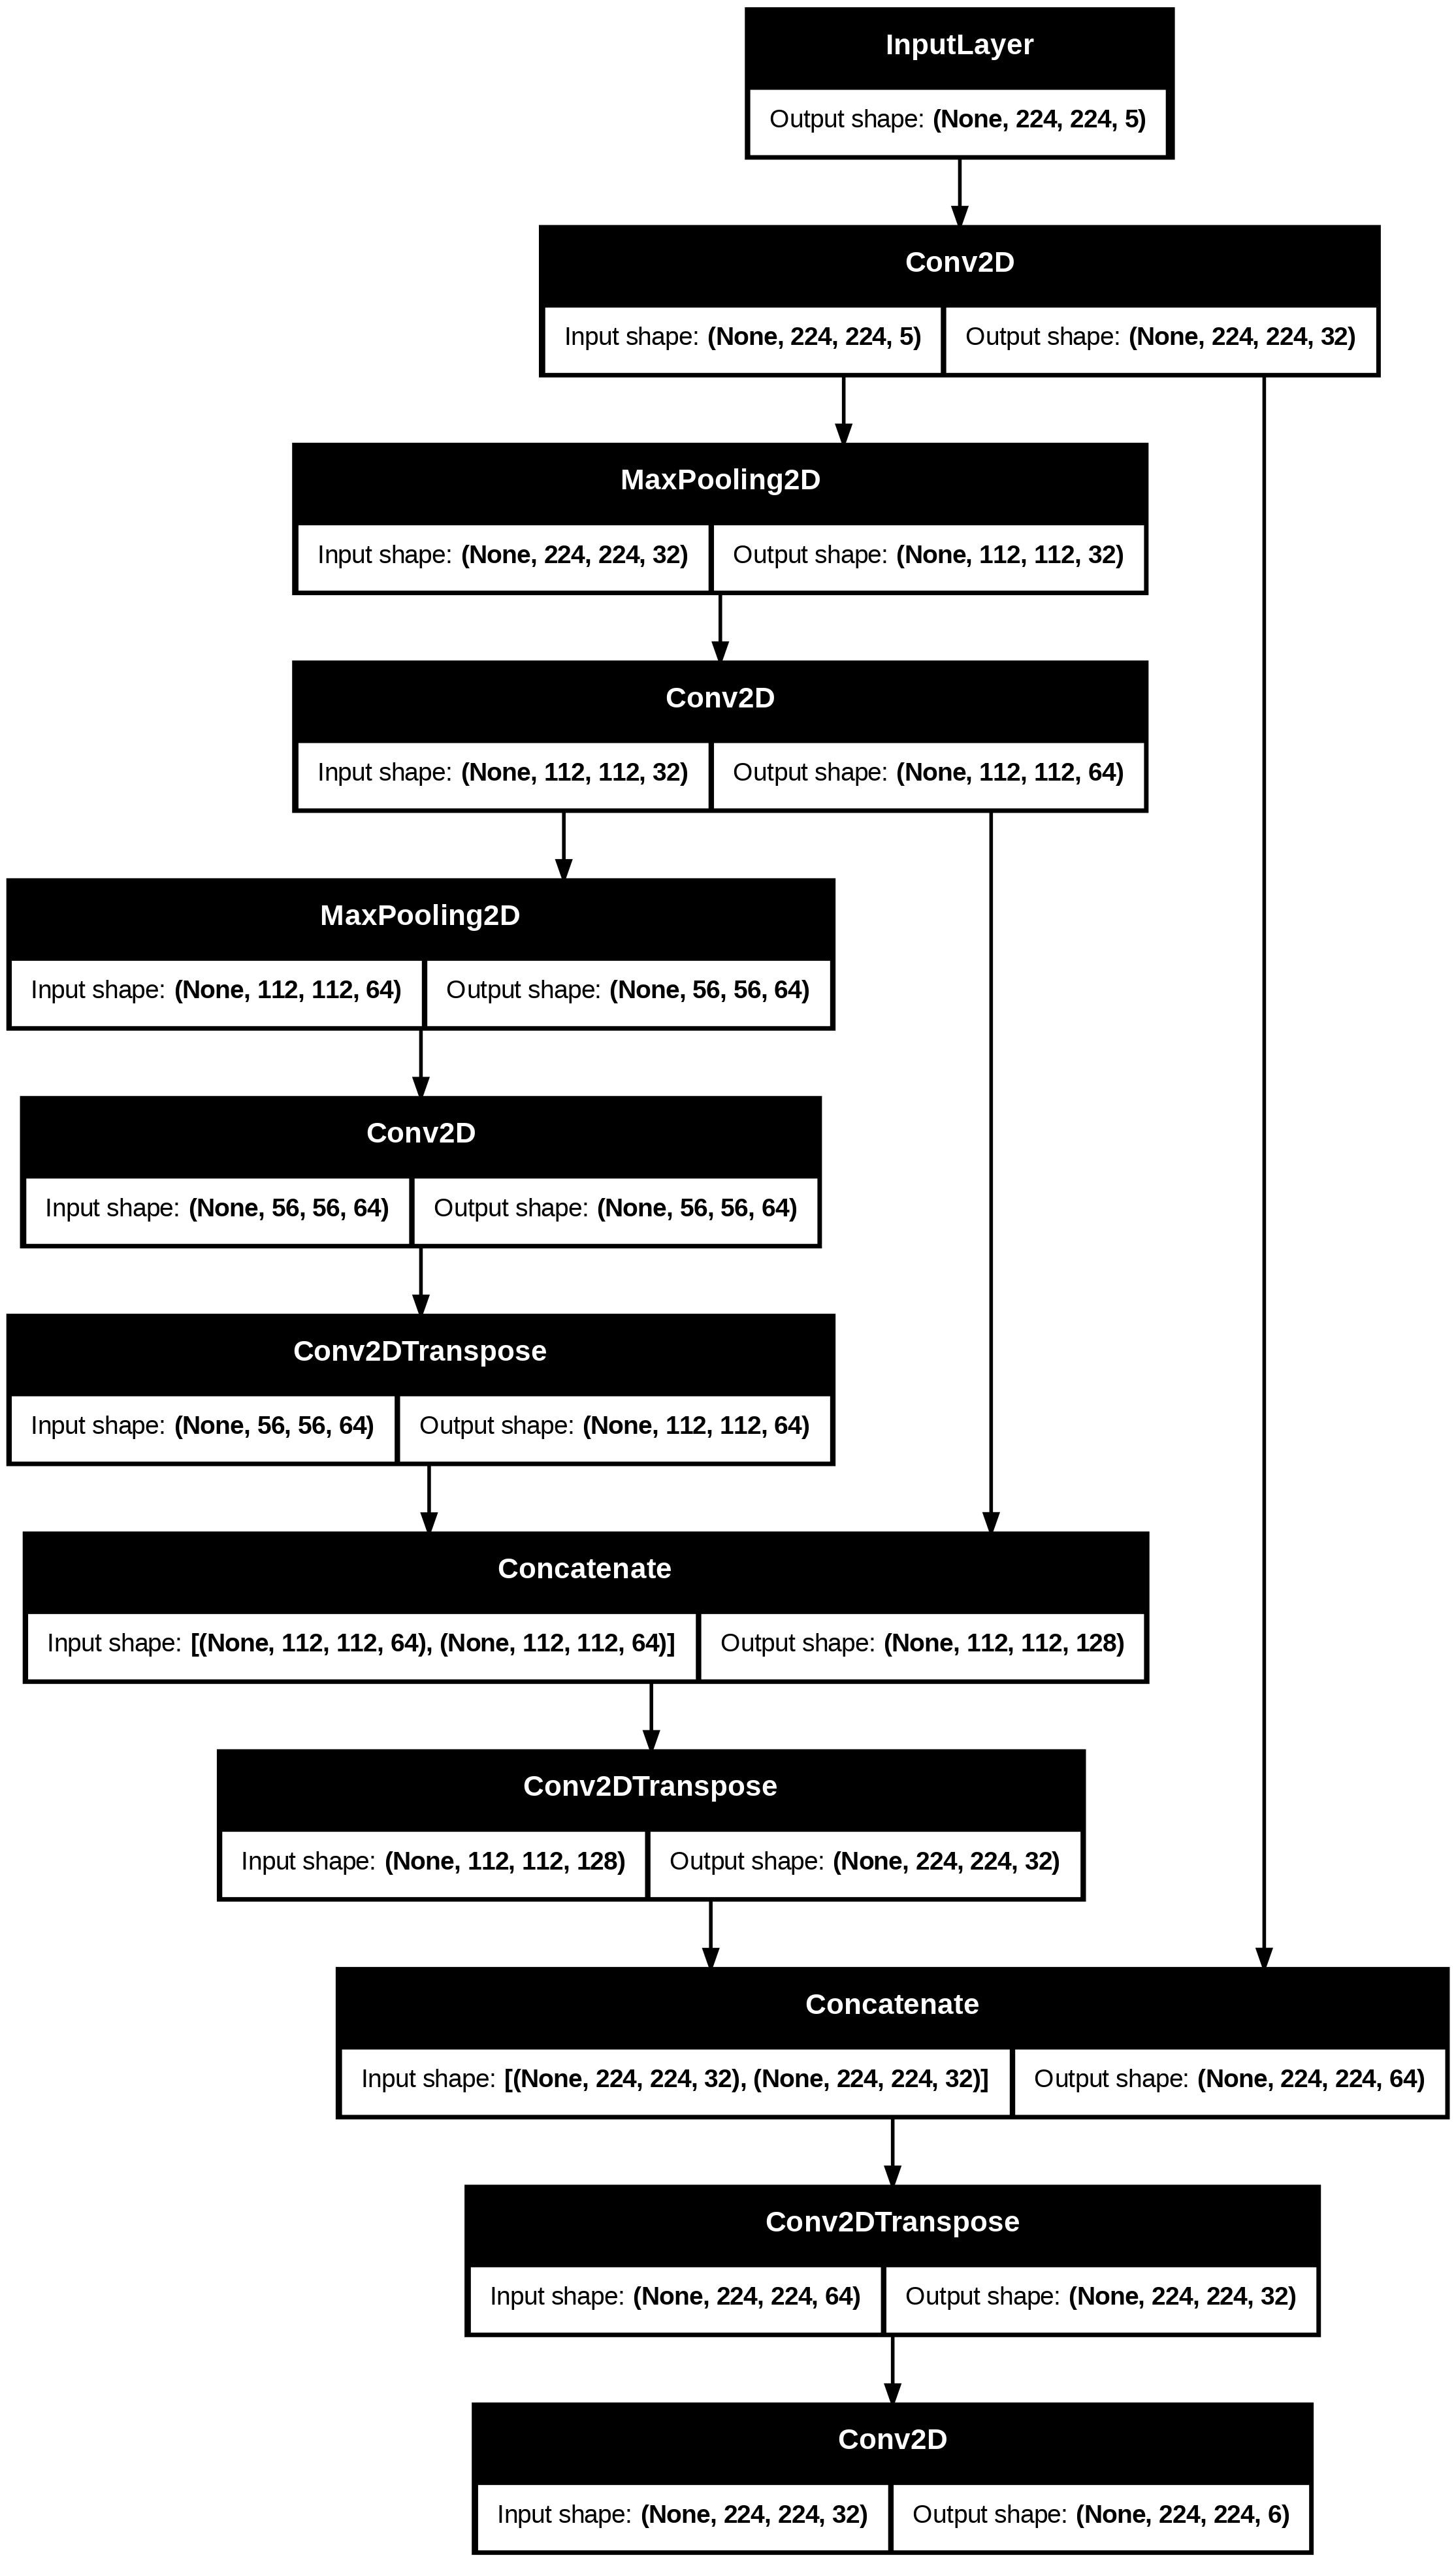

In [ ]:
# Show model parameters and model architecture image
model.summary()
tf.keras.utils.plot_model(model, show_shapes=True)

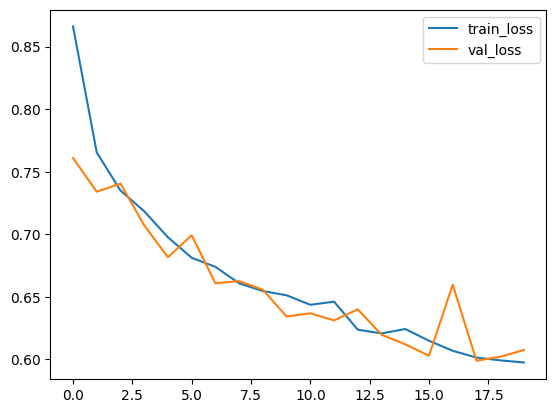

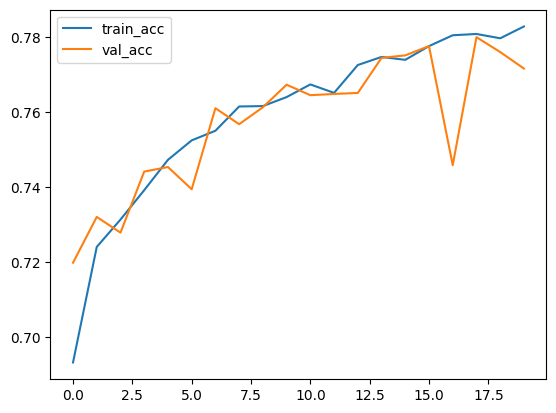

In [ ]:
# Plot train and validation loss
plt.figure()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

# Plot train and validation accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

In [ ]:
# Load best model and run it on test set
best_encoder_decoder = tf.keras.models.load_model("best_encoder_decoder.keras")
test_loss, test_acc = best_encoder_decoder.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)


125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.7815 - loss: 0.6065
Test Loss: 0.631564199924469
Test Accuracy: 0.7723621129989624


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


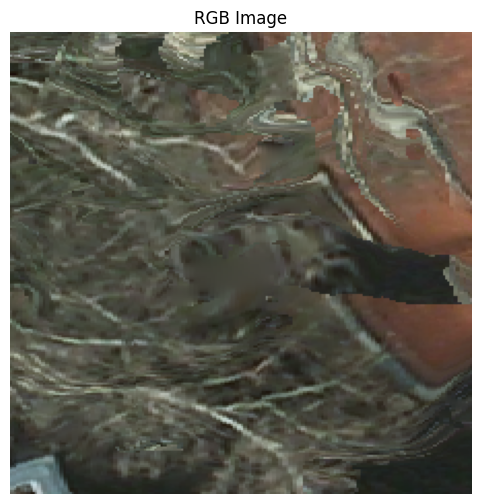

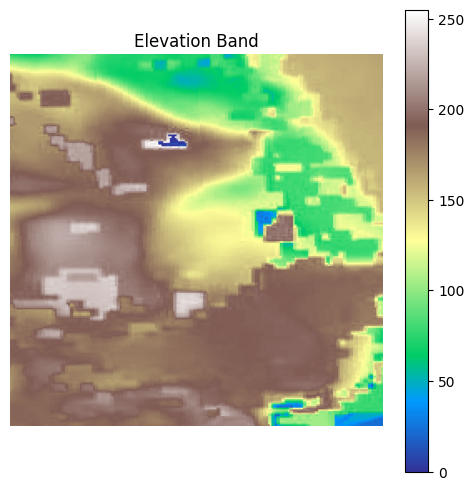

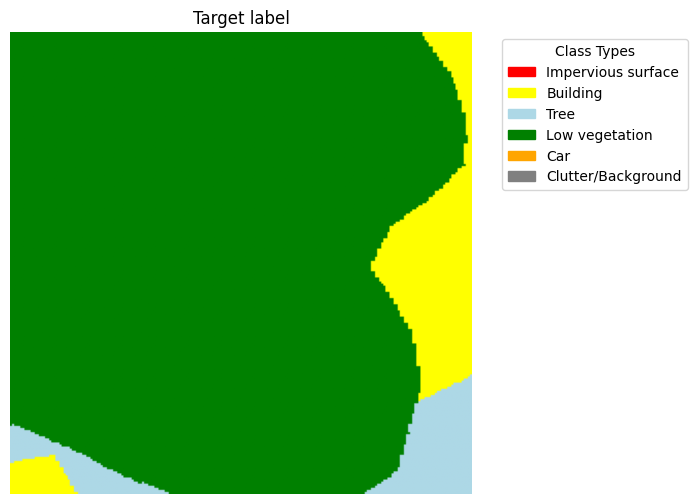

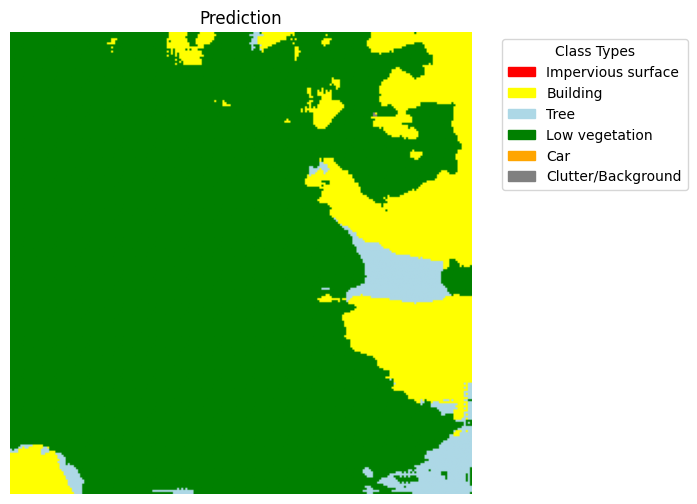

In [ ]:
# See predictions for 1 test set image

# Or just: for image_batch, label_batch in test_dataset.take(1):
for image_batch, label_batch in test_dataset.shuffle(1000).take(1):
    image = image_batch[0]
    label = label_batch[0]
    break

pred = model.predict(tf.expand_dims(image, axis=0))
pred_map = tf.argmax(pred[0], axis=-1)
true_map = tf.argmax(label, axis=-1)

image_denorm = image * std_tf + mean_tf
rgb = image_denorm[:, :, 0:3]
rgb = tf.clip_by_value(rgb / 255.0, 0, 1)
elevation = image_denorm[:, :, 4]

cmap = mcolors.ListedColormap(colors)

# RGB
plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.title("RGB Image")
plt.axis("off")
plt.show()

# Elevation
plt.figure(figsize=(6,6))
plt.imshow(elevation, cmap="terrain")
plt.title("Elevation Band")
plt.colorbar()
plt.axis("off")
plt.show()

# Target label
plt.figure(figsize=(6,6))
plt.imshow(true_map, cmap=cmap, vmin=0, vmax=5)
plt.title("Target label")
plt.axis("off")

patches = [
    mpatches.Patch(color=colors[i], label=classNames[i])
    for i in range(6)
]

plt.legend(
    handles=patches,
    title="Class Types",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

# Prediction
plt.figure(figsize=(6,6))
plt.imshow(pred_map, cmap=cmap, vmin=0, vmax=5)
plt.title("Prediction")
plt.axis("off")

plt.legend(
    handles=patches,
    title="Class Types",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()